[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Weight Decay Regularization

Now that we have characterized the problem of overfitting,
we can introduce our first regularization technique.
Recall that we can mitigate overfitting
by collecting more training data.
However, that can be costly, time consuming,
or entirely out of our control,
making it infeasible.
For now, we can assume that we already have
as much high-quality data as our resources permit
and focus the tools at our disposal
when the dataset is taken as a given.

In [1]:
import torch
from torch import nn
import numpy as np
from matplotlib import pyplot as plt

## Weight Decay

**Weight decay** operates by **reducing the range** of values that the parameters of a model will take.
More commonly called **$\ell_2$ regularization**, weight decay might be the most widely used regularization technique.
The technique is motivated by the basic intuition that among all functions $f$,
the function $f = const$ (assigning a constant value regardless of the input) is in some sense the *simplest*, and that we can measure the complexity
of a function by the distance of its parameters (excluding the bias) from zero.
But how precisely should we measure the distance between a function and zero?
There is no single right answer.
One simple approach is to measure the complexity of a linear function
$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x}$ by some norm of its weight vector, e.g., $\| \mathbf{w} \|^2$.

The most common method for ensuring a small weight vector is to add its norm as a penalty term to the loss function.
Thus we replace our original objective, *minimizing the loss on the training labels*, with a new objective, *minimizing the sum of the prediction loss and the penalty term*.
In this setup, the solution is a tradeoff between these two objectives. 

While this is a general technique, we will apply this to linear regression where our loss is given by

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

Recall that $\mathbf{x}^{(i)}$ are the features,
$y^{(i)}$ is the label for any data example $i$, and $(\mathbf{w}, b)$
are the weight and bias parameters, respectively.
To penalize the size of the weight vector,
we will add $\| \mathbf{w} \|^2$ to the loss function.
But how should the model trade off the
standard loss for this new additive penalty?
In practice, we implement this trade-off via the **regularization constant** $\lambda$, a nonnegative hyperparameter that we choose using validation data.  Our cost function is now:

$$L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2.$$

For $\lambda = 0$, we recover our original loss function.
For $\lambda > 0$, we restrict the size of $\| \mathbf{w} \|$.
We divide the penalty by $2$ by convention:
the $2$ that comes down when we differentiate $\|\mathbf{w}\|^2$ cancels it,
so the gradient of the penalty is simply $\lambda\mathbf{w}$.
(As in the earlier notebooks, the loss itself has no factor of $\frac{1}{2}$, matching `nn.MSELoss`.)
The astute reader might wonder why we work with the squared norm and not the norm itself.
We do this for computational convenience:  By squaring the $\ell_2$ norm, we remove the square root.
This makes the derivative of the penalty easy to compute.

### Question

* Describe what happens when $\lambda=0$ and when $\lambda$ is very large.
  

### Model update equations for regularized linear regression

Using the same notation as the earlier notebook,
minibatch stochastic gradient descent updates
for $\ell_2$-regularized regression are as follows:

$$\begin{aligned}
\mathbf{w} & \leftarrow \mathbf{w} - \eta\lambda\mathbf{w} - \frac{2 \eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right).
\end{aligned}$$

As before, we update $\mathbf{w}$ based on the amount
by which our estimate differs from the observation and at the same time shrink the size of $\mathbf{w}$ towards zero.
That is why the method is sometimes called **weight decay**:
given the penalty term alone, our optimization algorithm *decays* the weight at each step of training.
Smaller values of $\lambda$ correspond to less constrained $\mathbf{w}$,
whereas larger values of $\lambda$ constrain $\mathbf{w}$ more considerably.
Note that this is a soft-constraint, namely **shrinking** the size of the weights.
Whether we include a corresponding bias penalty  can vary across implementations,  and may vary across layers of a neural network.
Typically, we do not regularize the bias term.

### Demonstrating the benefit of weight decay

We will illustrate the benefit of weight decay 
using a simple high dimensional synthetic dataset.

We generate synthetic data as before:

$$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \textrm{ where }
\epsilon \sim \mathcal{N}(0, 0.01^2).$$

In this synthetic dataset, our label is given 
by an underlying linear function of our inputs,
corrupted by Gaussian noise  with zero mean and standard deviation 0.01.
To make the effects of overfitting pronounced we will increase the dimensionality of our problem to $d = 200$
and work with a small training set with only 20 examples.


We build a small `Data` class that generates the synthetic dataset and serves it
in minibatches through standard PyTorch `DataLoader`s, with no external dependencies.

In [2]:
class Data:
    """Synthetic high-dimensional linear-regression dataset."""
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.num_train = num_train
        self.num_val = num_val
        self.num_inputs = num_inputs
        self.batch_size = batch_size
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def _loader(self, X, y, train):
        dataset = torch.utils.data.TensorDataset(X, y)
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)

    def train_dataloader(self):
        return self._loader(self.X[:self.num_train], self.y[:self.num_train], train=True)

    def val_dataloader(self):
        return self._loader(self.X[self.num_train:], self.y[self.num_train:], train=False)

## Implementation from Scratch

Now, let's implement weight decay from scratch.
Since minibatch stochastic gradient descent is our optimizer, we just need to add the squared $\ell_2$ penalty to the original loss function.

### The $\ell_2$ Norm Penalty

Here's an implementation of the components that go into defining our loss function:


In [3]:
def l2_penalty(w):
    return (w ** 2).sum() / 2

def MSEloss(y_hat, y):
    l = (y_hat - y) ** 2
    return l.mean()

### Model Implementation

In PyTorch, models simply define how to map an input to the output using the `forward` function.  So our weight decay regression will use the same model implementation as our regular linear regression.  Only the loss function needs to change.

In [4]:
class LinearRegressionScratch:
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, sigma=0.01):
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

    def parameters(self):
        return self.w, self.b

    def __call__(self, X):
        return self.forward(X)

    def forward(self, X):
        return torch.matmul(X, self.w) + self.b

    # train()/eval() are no-ops here (no dropout/batchnorm), included so the
    # training loop reads the same as it will for later nn.Module models.
    def train(self):
        pass

    def eval(self):
        pass

We also implement minibatch SGD from scratch, so the entire from-scratch
section is self-contained:

In [5]:
class SGD:
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr

    def step(self):
        for p in self.params:
            p -= self.lr * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

### Training without Regularization

The following code fits our model on a training set with 20 examples and evaluates it on the validation set with 100 examples.  Due to the small number of examples, and high dimensionality, even a linear model can overfit.

To demonstrate overfitting we will first train a model with `lambd = 0`, disabling weight decay.  

In [6]:
torch.manual_seed(0)
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)

### Why this dataset is hard

Before training, it is worth looking at the feature matrix we just built.  It has 200 features and
only 20 training examples, so the columns cannot possibly be linearly independent: any 20 vectors
span at most a 20-dimensional space.

In [7]:
X_train_wd = data.X[:data.num_train].numpy()
gram = X_train_wd.T @ X_train_wd / len(X_train_wd)      # the 200 x 200 matrix X'X/n
eigenvalues_wd = np.linalg.eigvalsh(gram)

print(f"feature matrix X        : {X_train_wd.shape[0]} examples x {X_train_wd.shape[1]} features")
print(f"rank of X              : {np.linalg.matrix_rank(X_train_wd)}  (at most the number of examples)")
print()
print(f"eigenvalues of X'X/n   : {len(eigenvalues_wd)} of them, but only {np.linalg.matrix_rank(X_train_wd)} can be nonzero")
print(f"   largest             : {eigenvalues_wd[-1]:.4f}")
print(f"   smallest            : {eigenvalues_wd[0]:.3e}")
print()
print("The smallest is zero.  The tiny nonzero value printed above -- negative, which an")
print("eigenvalue of X'X cannot be -- is floating-point noise around an exact zero.  So")
print("kappa = lambda_max / lambda_min is infinite, and what numpy reports for it,")
print(f"{np.linalg.cond(gram):.2e}, is a property of the arithmetic rather than of the data.")

feature matrix X        : 20 examples x 200 features
rank of X              : 20  (at most the number of examples)

eigenvalues of X'X/n   : 200 of them, but only 20 can be nonzero
   largest             : 18.0823
   smallest            : -5.677e-07

The smallest is zero.  The tiny nonzero value printed above -- negative, which an
eigenvalue of X'X cannot be -- is floating-point noise around an exact zero.  So
kappa = lambda_max / lambda_min is infinite, and what numpy reports for it,
3.93e+10, is a property of the arithmetic rather than of the data.


The smallest eigenvalue is zero, so the condition number is infinite.  This is the extreme case of the situation we met on the auto-mpg data: there are
directions in weight space -- many of them here -- along which the training loss does not change at
all.  The training data cannot distinguish between solutions that differ along those directions, and
nothing in the least-squares objective prefers one over another.

That is the real reason this dataset overfits so readily.  It is not only that there is little data;
it is that the problem, as posed, does not have a unique answer.

In [8]:
model = LinearRegressionScratch(num_inputs=200, sigma=0.01)
optimizer = SGD(model.parameters(), lr=0.001)

In [9]:
def train_weight_decay(data, model, optimizer, lambd, epochs) :
    # overall loss value for each epoch:
    loss_train = []
    mse_train = []
    mse_valid = []
    for epoch in range(epochs) :
        model.train()
        loss_values = [] # loss values for each batch
        mse_values = []
        for batch_X, batch_y in data.train_dataloader() :
            preds = model(batch_X)
            #==================================================================
            loss = MSEloss(preds, batch_y) + lambd * l2_penalty(model.w)
            #==================================================================        
            loss_values.append(loss.item())
            mse_values.append(MSEloss(preds, batch_y).item())
            optimizer.zero_grad()
            with torch.no_grad() :
                loss.backward()
                optimizer.step()
        loss_train.append(np.mean(loss_values))
        mse_train.append(np.mean(mse_values))
        model.eval()
        mse_values = []
        for batch_X, batch_y in data.val_dataloader() :
            with torch.no_grad():
                preds = model(batch_X)
                loss = MSEloss(preds, batch_y)
                mse_values.append(loss.item())
        mse_valid.append(np.mean(mse_values))
    return loss_train,mse_train,mse_valid

In [10]:
loss_train, mse_train, mse_valid = train_weight_decay(
    data, model, optimizer, lambd=0, epochs=500)

Let's define a small plotting helper, since we'll make this same train/validation
curve several times:

In [11]:
def plot_curves(train, valid, train_label='mse train', valid_label='mse validation'):
    plt.figure(figsize=(5, 3))
    plt.plot(range(1, len(train) + 1), train, label=train_label)
    plt.plot(range(1, len(valid) + 1), valid, label=valid_label)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend();

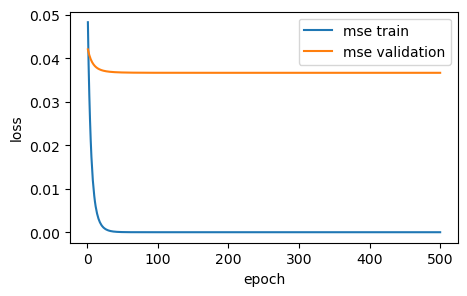

In [12]:
plot_curves(mse_train, mse_valid)

We also report the squared $\ell_2$ norm of the learned weights, $\|\mathbf{w}\|^2/2$,
which measures how large the weights have grown:

In [13]:
print(f'squared L2 norm of weights: {l2_penalty(model.w).item():.4f}')

squared L2 norm of weights: 0.0106


We observe decreasing training error but not the
validation error, a textbook case of overfitting.

### Training with Regularization

Now we train the same model with $\lambda = 3$. We re-instantiate the model and
optimizer so we start from a fresh set of weights.

In [14]:
model = LinearRegressionScratch(num_inputs=200, sigma=0.01)
optimizer = SGD(model.parameters(), lr=0.001)

In [15]:
loss_train, mse_train, mse_valid = train_weight_decay(
    data, model, optimizer, lambd=3, epochs=500)

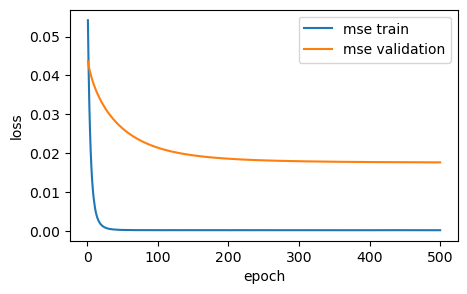

In [16]:
plot_curves(mse_train, mse_valid)

The validation error is now substantially lower, and the weights are much smaller:

In [17]:
print(f'final validation mse:        {mse_valid[-1]:.4f}')
print(f'squared L2 norm of weights:  {l2_penalty(model.w).item():.4f}')

final validation mse:        0.0177
squared L2 norm of weights:  0.0006


### What weight decay does to the eigenvalues

Weight decay repairs this in a way that can be stated in one line.  Ignoring the bias, the objective we trained is

$$\frac{1}{n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \frac{\lambda}{2} \|\mathbf{w}\|^2 .$$

Setting its gradient to zero gives the modified normal equations

$$\left(\frac{2}{n}\mathbf{X}^\top\mathbf{X} + \lambda \mathbf{I}\right)\mathbf{w} = \frac{2}{n}\mathbf{X}^\top\mathbf{y}.$$

(Up to a rescaling of $\lambda$, this is the classic ridge regression objective $\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \lambda \|\mathbf{w}\|^2$.)
The matrix on the left is the Hessian of the regularized loss: the Hessian $\frac{2}{n}\mathbf{X}^\top\mathbf{X}$ of the unregularized loss plus $\lambda \mathbf{I}$.
Adding $\lambda \mathbf{I}$ leaves the eigen*vectors* alone and shifts every eigen*value* up by
$\lambda$.  Writing $h_{\max}$ and $h_{\min}$ for the largest and smallest eigenvalues of $\frac{2}{n}\mathbf{X}^\top\mathbf{X}$, the condition number becomes

$$\kappa_\lambda = \frac{h_{\max} + \lambda}{h_{\min} + \lambda},$$

which is finite even when $h_{\min} = 0$, and decreases monotonically as $\lambda$ grows.
Because the $\lambda$ here is the same one passed to the training code, the table below includes $\lambda = 3$, the value we trained with.

In [18]:
hessian = 2 * gram                              # Hessian of the unregularized loss, (2/n) X'X
h_max, h_min = 2 * eigenvalues_wd[-1], 0.0      # the exact smallest eigenvalue is zero

print(f"{'lambda':>10} {'predicted kappa':>18} {'measured kappa':>17}")
for lam in (0.0, 1e-4, 1e-2, 1e-1, 1.0, 3.0):
    predicted = (h_max + lam) / (h_min + lam) if lam > 0 else np.inf
    measured  = np.linalg.cond(hessian + lam * np.eye(len(hessian)))
    print(f"{lam:>10g} {predicted:>18.3e} {measured:>17.3e}")
print()
print("First row: the unregularized problem.  kappa is infinite; the finite value numpy")
print("reports is rounding error.  Elsewhere the formula and the measurement agree -- the")
print("small gap at lambda=1e-4 is that same rounding noise, which lambda has not yet swamped.")

    lambda    predicted kappa    measured kappa
         0                inf         3.928e+10
    0.0001          3.616e+05         3.658e+05
      0.01          3.617e+03         3.618e+03
       0.1          3.626e+02         3.626e+02
         1          3.716e+01         3.716e+01
         3          1.305e+01         1.305e+01

First row: the unregularized problem.  kappa is infinite; the finite value numpy
reports is rounding error.  Elsewhere the formula and the measurement agree -- the
small gap at lambda=1e-4 is that same rounding noise, which lambda has not yet swamped.


Away from $\lambda = 0$ the formula and the measurement agree to about three significant figures, as they must, and each tenfold
increase in $\lambda$ buys roughly a tenfold reduction in $\kappa$.  (At $\lambda = 10^{-4}$ the two
differ slightly: the shift is not yet large enough to dominate the rounding noise in the computed
eigenvalues -- itself a reminder of what an infinite condition number does to arithmetic.)

This explains two things at once.  The *statistical* story for weight decay is that penalizing large coefficients reduces variance and
improves generalization.  The *numerical* story is that shifting the eigenvalue spectrum makes the problem well posed, so the solution stops being sensitive to noise, to rounding, and to the choice of optimizer.  They are the same
intervention, and $\lambda$ is the knob that controls both.

The condition number of the regularized problem is
smaller than that of the original.  As a result, the regularized problem is not only better determined but *easier to
optimize*, and gradient descent converges faster on it.  We will revisit this issue again when we discuss variants of SGD.

With weight decay the training error rises slightly (we are no longer free to fit
the training set perfectly), but the validation error drops by roughly a factor of two,
and the weight norm shrinks by more than an order of magnitude. This is exactly the
tradeoff we wanted: a little more bias in exchange for much less variance.

## Concise Implementation in PyTorch

Because weight decay is ubiquitous
in neural network optimization,
PyTorch makes it especially convenient,
integrating weight decay into the optimization algorithm itself
for easy use in combination with any loss function.
Moreover, this integration serves a computational benefit,
allowing implementation tricks to add weight decay to the algorithm,
without much computational overhead.

### Where to put the penalty

There is an important subtlety in how PyTorch implements weight decay. Our from-scratch
version **added the regularization term to the loss**.  

Its gradient is $\lambda\mathbf{w}$. 

PyTorch's `weight_decay`, by contrast, adds the term $\lambda\mathbf{w}$ directly into the gradient:

$$g \leftarrow g + \texttt{weight\_decay}\cdot\mathbf{w}.$$

Recall that $\lambda\mathbf{w}$ is the gradient of the regularizer $\lambda \cdot \frac{\|\mathbf{w}\|^2}{2}.$
Because the $\frac{1}{2}$ in our penalty cancels exactly when we differentiate $\|\mathbf{w}\|^2$,
both approaches contribute the *same* term $\lambda\mathbf{w}$ to the gradient. This is why we can obtain the same results in both implementations.

### Applying weight decay to the right parameters

In PyTorch we specify the weight decay hyperparameter directly
through the parameter `weight_decay` when instantiating our optimizer.
By default, PyTorch decays both weights and biases simultaneously, but
we can configure the optimizer to handle different parameters
according to different policies.
Here, we only set `weight_decay` for
the weights (the `net.weight` parameters), hence the 
bias (the `net.bias` parameter) will not decay.


In [19]:
class LinearRegression(nn.Module):
    """Linear regression using PyTorch's high-level API."""
    def __init__(self, num_inputs, sigma=0.01):
        super().__init__()
        self.net = nn.Linear(num_inputs, 1)
        # Match the initialization used in the from-scratch model so the two
        # sections are directly comparable.
        self.net.weight.data.normal_(0, sigma)
        self.net.bias.data.fill_(0)

    def forward(self, X):
        return self.net(X)

In [20]:
lambd = 0
model = LinearRegression(num_inputs=200)
# A tempting but incorrect choice:
#   optimizer = torch.optim.SGD(model.parameters(), lr=0.001, weight_decay=lambd)
# That applies weight decay to ALL parameters, including the bias.
# Instead we put the weight and bias in separate parameter groups so that only
# the weight vector is decayed:
optimizer = torch.optim.SGD([
    {'params': model.net.weight, 'weight_decay': lambd},
    {'params': model.net.bias}], lr=0.001)
# A note regarding the above call to SGD:
# Each dictionary specifies a parameter group; 'params' is the field holding that group's tensors, 
# and every other key in the dictionary is a hyperparameter that overrides the defaults for those tensors.
loss_fn = nn.MSELoss()

In [21]:
def train_weight_decay_concise(data, model, optimizer, epochs) :
    loss_train = [] 
    loss_valid = []
    for epoch in range(epochs) :
        model.train()
        loss_values = [] # loss values for each batch
        for batch_X, batch_y in data.train_dataloader() :
            preds = model(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
            optimizer.zero_grad() 
            # needs to be called becuase by default PyTorch accumulates gradients
            with torch.no_grad() :
                loss.backward()
                optimizer.step()
        loss_train.append(np.mean(loss_values))
        model.eval()
        loss_values = []
        for batch_X, batch_y in data.val_dataloader() :
            with torch.no_grad():
                preds = model(batch_X)
                loss = loss_fn(preds, batch_y)
                loss_values.append(loss.item())
        loss_valid.append(np.mean(loss_values))
    return loss_train,loss_valid

In [22]:
loss_train, loss_valid = train_weight_decay_concise(
    data, model, optimizer, epochs=500)

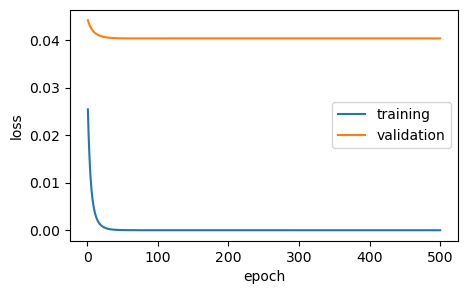

In [23]:
plot_curves(loss_train, loss_valid, 'training', 'validation')

And again with $\lambda = 3$:

In [24]:
lambd = 3
model = LinearRegression(num_inputs=200)
optimizer = torch.optim.SGD([
    {'params': model.net.weight, 'weight_decay': lambd},
    {'params': model.net.bias}], lr=0.001)
loss_fn = nn.MSELoss()

In [25]:
loss_train, loss_valid = train_weight_decay_concise(
    data, model, optimizer, epochs=500)

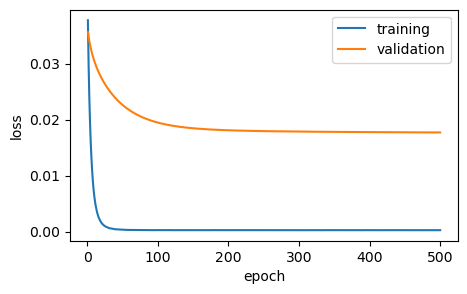

In [26]:
plot_curves(loss_train, loss_valid, 'training', 'validation')

In [27]:
print(f'final training mse:   {loss_train[-1]:.4f}')
print(f'final validation mse: {loss_valid[-1]:.4f}')

final training mse:   0.0003
final validation mse: 0.0177


The plot looks similar to that when
we implemented weight decay from scratch.
However, this version runs faster
and is easier to implement,
benefits that will become more
pronounced as you address larger problems and implement more complex networks.


## Comments

You might ask why we work with the $\ell_2$ norm and not, say, the $\ell_1$ norm.
In fact, other choices are valid and popular.
While $\ell_2$-regularized linear models constitute the classic *ridge regression* algorithm, $\ell_1$-regularized linear regression is a similarly fundamental method,  popularly known as *lasso regression*.
One reason to work with the $\ell_2$ norm is that it places an outsize penalty
on large components of the weight vector.
This biases our learning algorithm
towards models that distribute weight evenly across a larger number of features.
In practice, this might make them more robust to measurement error in a single variable.
By contrast, $\ell_1$ penalties lead to models that concentrate weights on a small set of features by reducing the other weights to zero.
This gives us an effective method for *feature selection*, which may be desirable for other reasons.
For example, if our model only relies on a few features, then we may not need to collect, store, or transmit data for the other features. 


## Summary

Regularization is a common method for dealing with overfitting. Classical regularization techniques add a penalty term to the loss function (when training) to reduce the complexity of the learned model.
One particular choice for keeping the model simple is using an $\ell_2$ penalty. This leads to weight decay in the update steps of the minibatch stochastic gradient descent algorithm.
In practice, the weight decay functionality is provided in optimizers from deep learning frameworks.
Different sets of parameters can have different update behaviors within the same training loop.




## Exercises

1. Experiment with the value of $\lambda$ in the from-scratch implementation. Plot the
   final training and validation error as a function of $\lambda$. What value gives the
   best validation error?
2. In the concise implementation, what happens if you (incorrectly) apply weight decay to
   the bias term as well? Does it noticeably change the result here? Why might it matter
   more in other settings?
3. We used the squared $\ell_2$ norm as our penalty. Modify the from-scratch loss to use
   an $\ell_1$ penalty instead (lasso). How does the resulting weight vector differ?